In [4]:
#imports
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys 
import os
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))

import data_splitting as data
import preprocessing as prep
import metrics as mtr
import utils as utls
import models as mdls



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Desarrollo de Redes Neuronales para deteccion de letras y digitos manuscritos
(pensar otro titulo relacionado)

### 1. Analisis y Preprocesamiento de Datos

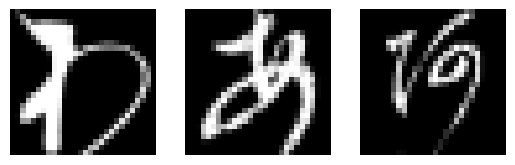

In [ ]:
Ximg, Yimg = prep.load_img("../data/raw/X_images.npy","../data/raw/Y_images.npy")

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(Ximg[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()



In [ ]:
#division del dataset y normalizacion

Xtrain, Ytrain, Xval, Yval, Xtest, Ytest = data.initial_split(Ximg, Yimg)

Xtrain, Xval, Xtest = prep.normalization(Xtrain, Xval, Xtest)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]
49
clase 0: 99 muestras
clase 1: 108 muestras
clase 2: 122 muestras
clase 3: 73 muestras
clase 4: 108 muestras
clase 5: 122 muestras
clase 6: 120 muestras
clase 7: 114 muestras
clase 8: 97 muestras
clase 9: 111 muestras
clase 10: 110 muestras
clase 11: 110 muestras
clase 12: 117 muestras
clase 13: 93 muestras
clase 14: 91 muestras
clase 15: 118 muestras
clase 16: 84 muestras
clase 17: 114 muestras
clase 18: 110 muestras
clase 19: 121 muestras
clase 20: 108 muestras
clase 21: 110 muestras
clase 22: 80 muestras
clase 23: 88 muestras
clase 24: 115 muestras
clase 25: 116 muestras
clase 26: 101 muestras
clase 27: 103 muestras
clase 28: 105 muestras
clase 29: 82 muestras
clase 30: 111 muestras
clase 31: 84 muestras
clase 32: 81 muestras
clase 33: 96 muestras
clase 34: 94 muestras
clase 35: 112 muestras
clase 36: 88 muestras
clase 37: 118 muest

### 2. Implementacion y Entrenamiento de una Red Neuronal Basica

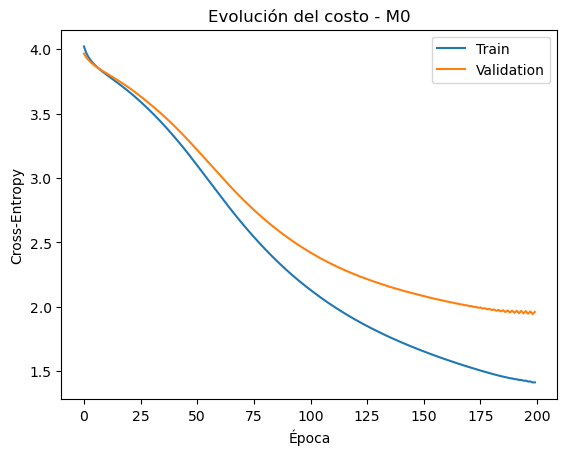

In [23]:
m0 = mdls.MLP([784, 128, 64, 49])
train_costs, val_costs = m0.fit(Xtrain, Ytrain, Xval, Yval, 200, 0.1)

plt.plot(train_costs, label='Train')
plt.plot(val_costs, label='Validation')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy')
plt.title('Evolución del costo - M0')
plt.legend()
plt.show()

In [ ]:
pred = m0.predict(Xval)

